# Lab 1. Linear transformations

### Plan for Lab 1. Linear transformations:
- Part 1
- Task 1
- Task 2
- Part 2
- Task 3
- Task 4
- Interactive (just for fun)
- Theoretical questions

## Part 1

In [1]:
import numpy as np
from shapes import lynx
from plotting import show
from transforms2d import *

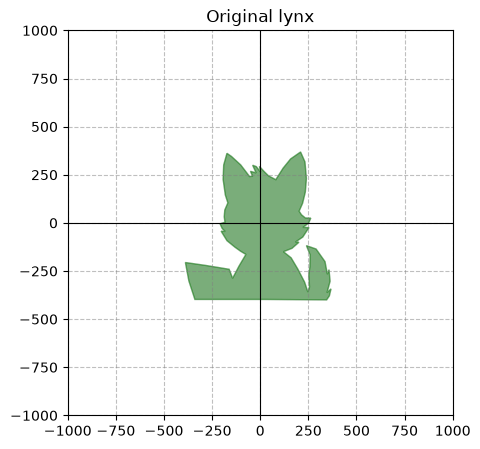

Original lynx
[[1. 0.]
 [0. 1.]]
True
True


In [2]:
show(lynx, lynx, np.eye(2), "Original lynx")

before = lynx.copy()
stretch(lynx, 2, 2)
print(np.array_equal(lynx, before))
print(np.allclose(rotation_matrix(0.7).T @ rotation_matrix(0.7), np.eye(2)))

### Task 1

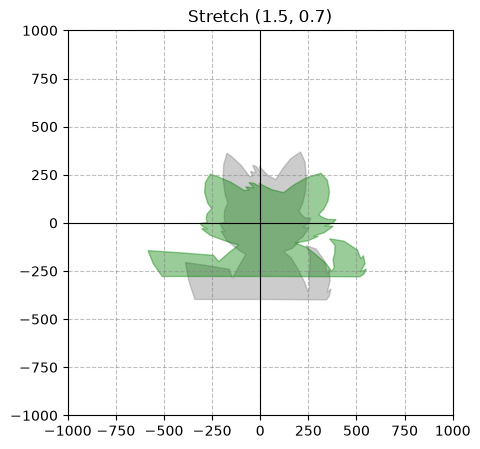

Stretch (1.5, 0.7)
[[1.5 0. ]
 [0.  0.7]]


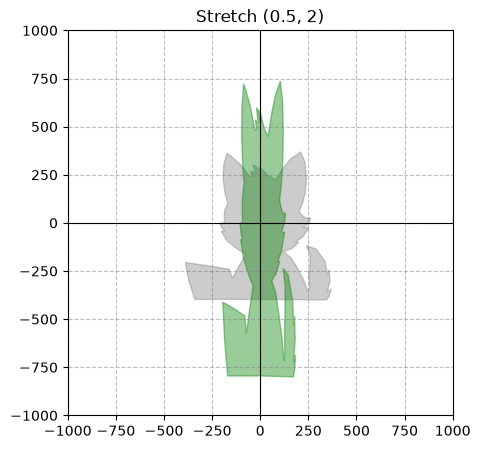

Stretch (0.5, 2)
[[0.5 0. ]
 [0.  2. ]]


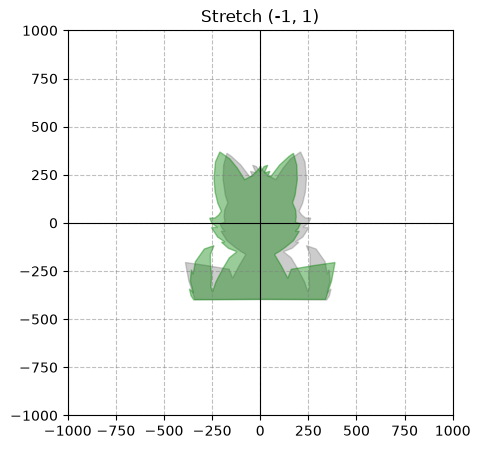

Stretch (-1, 1)
[[-1.  0.]
 [ 0.  1.]]


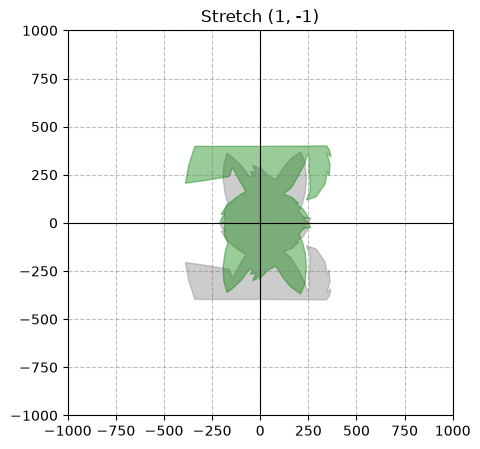

Stretch (1, -1)
[[ 1.  0.]
 [ 0. -1.]]


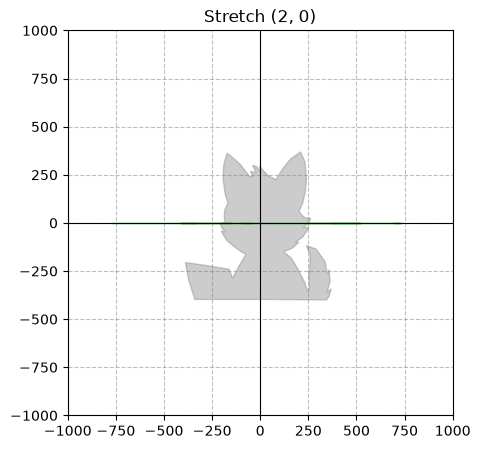

Stretch (2, 0)
[[2. 0.]
 [0. 0.]]


In [3]:
for a, b in [(1.5, 0.7), (0.5, 2), (-1, 1), (1, -1), (2, 0)]:
    Y = stretch(lynx, a, b)
    show(lynx, Y, stretch_matrix(a, b), f"Stretch ({a}, {b})")

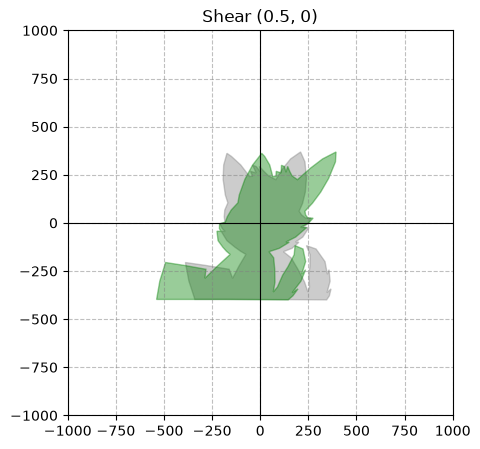

Shear (0.5, 0)
[[1.  0.5]
 [0.  1. ]]


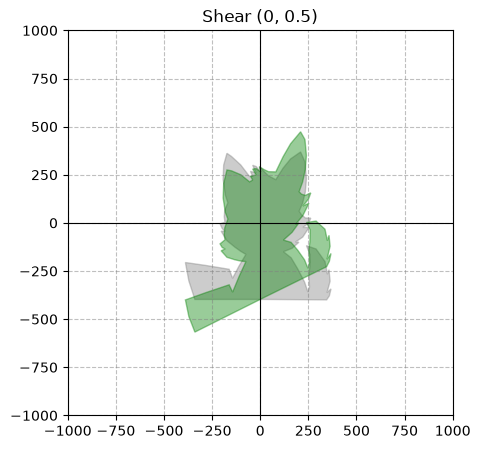

Shear (0, 0.5)
[[1.  0. ]
 [0.5 1. ]]


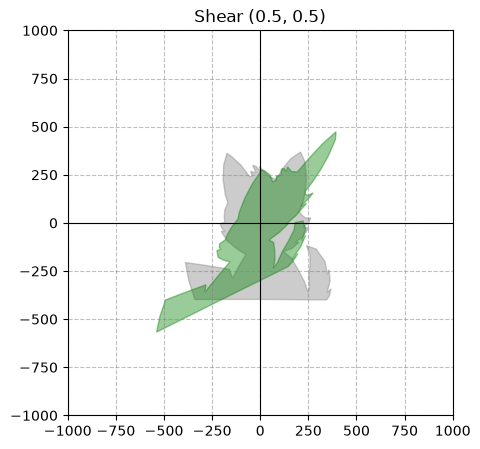

Shear (0.5, 0.5)
[[1.  0.5]
 [0.5 1. ]]


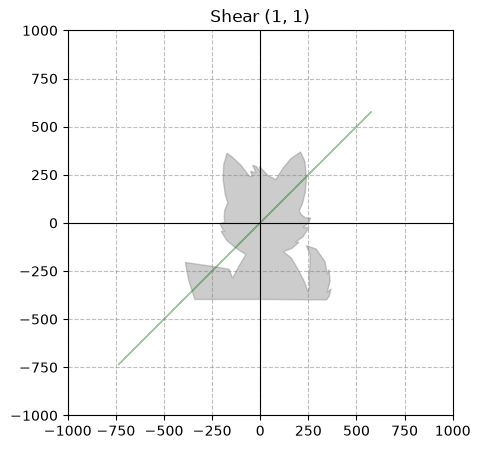

Shear (1, 1)
[[1. 1.]
 [1. 1.]]


In [4]:
for a, b in [(0.5, 0), (0, 0.5), (0.5, 0.5), (1, 1)]:
    Y = shear(lynx, a, b)
    show(lynx, Y, shear_matrix(a, b), f"Shear ({a}, {b})")

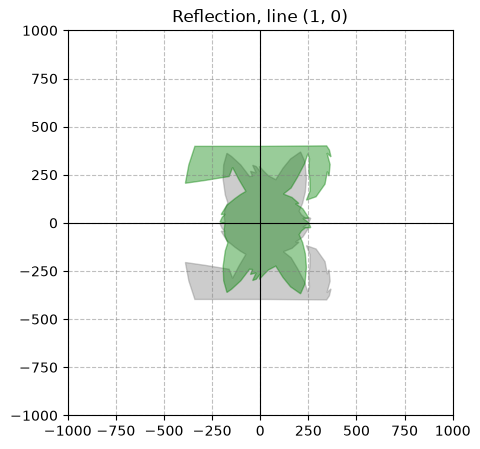

Reflection, line (1, 0)
[[ 1.  0.]
 [ 0. -1.]]


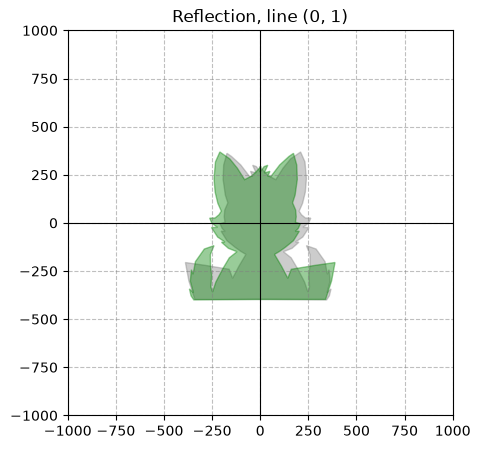

Reflection, line (0, 1)
[[-1.  0.]
 [ 0.  1.]]


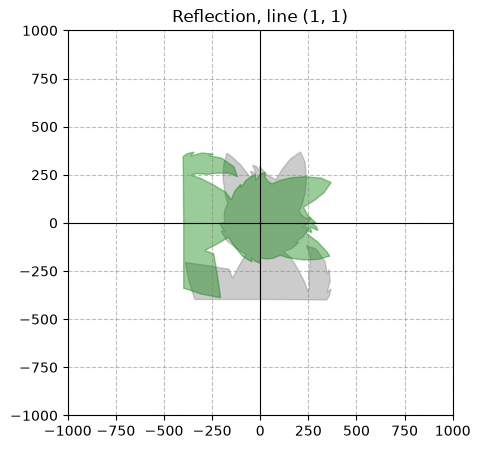

Reflection, line (1, 1)
[[0. 1.]
 [1. 0.]]


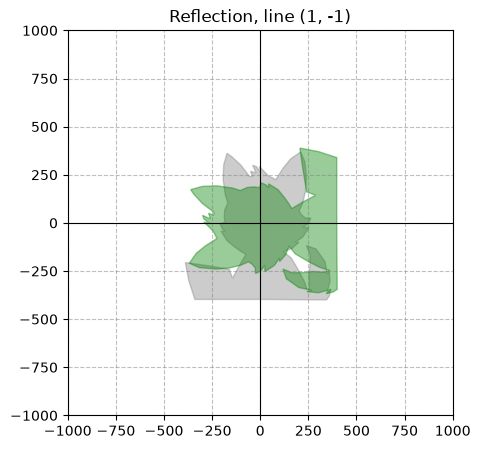

Reflection, line (1, -1)
[[ 0. -1.]
 [-1.  0.]]


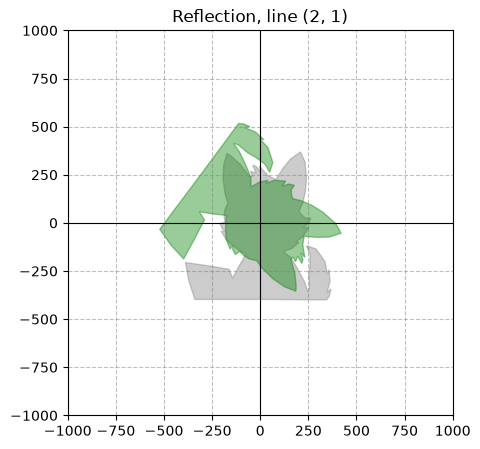

Reflection, line (2, 1)
[[ 0.6  0.8]
 [ 0.8 -0.6]]


In [5]:
for a, b in [(1, 0), (0, 1), (1, 1), (1, -1), (2, 1)]:
    Y = reflection(lynx, a, b)
    show(lynx, Y, reflection_matrix(a, b), f"Reflection, line ({a}, {b})")

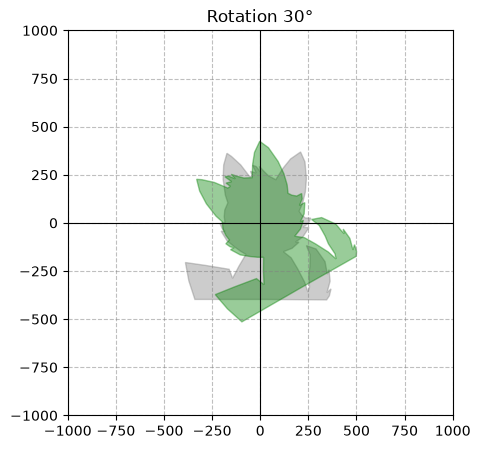

Rotation 30°
[[ 0.866 -0.5  ]
 [ 0.5    0.866]]


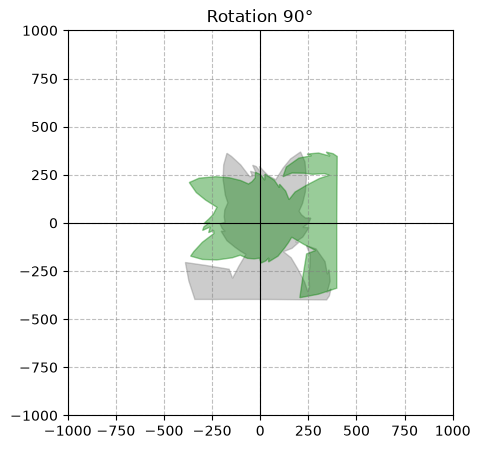

Rotation 90°
[[ 0. -1.]
 [ 1.  0.]]


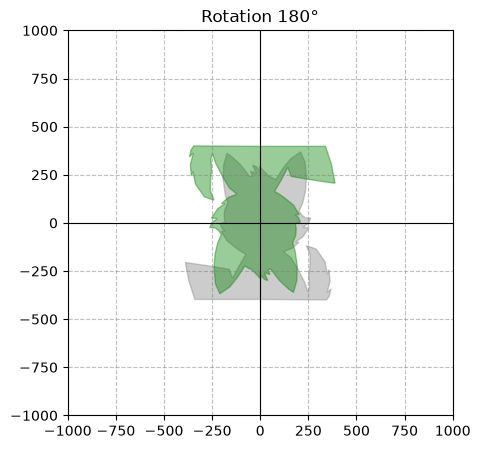

Rotation 180°
[[-1. -0.]
 [ 0. -1.]]


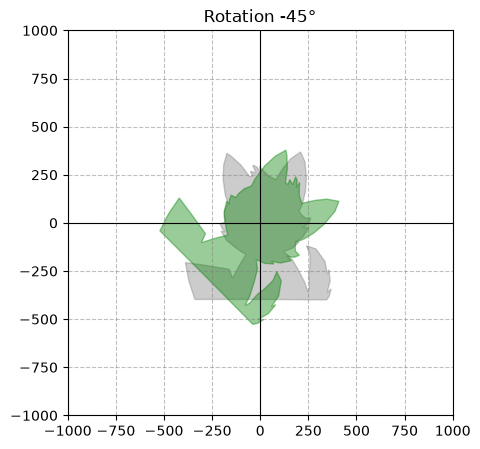

Rotation -45°
[[ 0.707  0.707]
 [-0.707  0.707]]


In [6]:
for deg in [30, 90, 180, -45]:
    theta = np.deg2rad(deg)
    Y = rotation(lynx, theta)
    show(lynx, Y, rotation_matrix(theta), f"Rotation {deg}°")

### Task 2

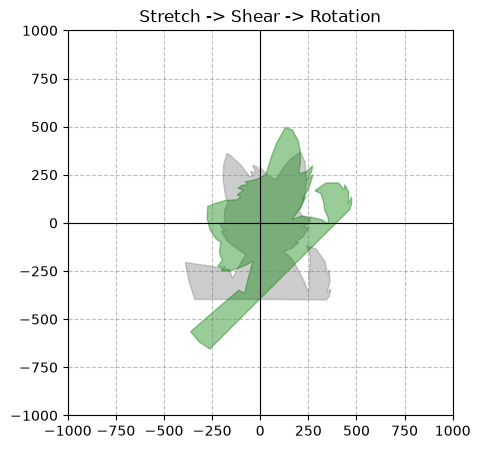

Stretch -> Shear -> Rotation
[[ 1.061 -0.247]
 [ 1.061  0.742]]


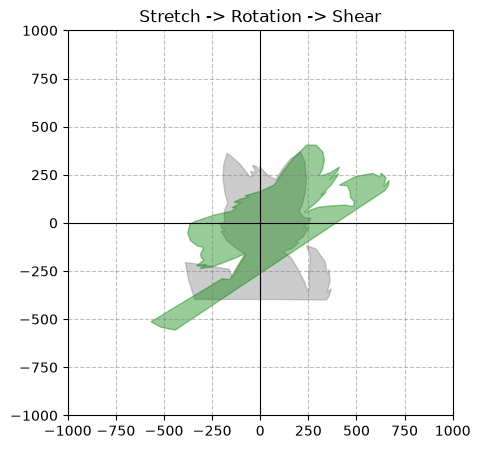

Stretch -> Rotation -> Shear
[[ 1.591 -0.247]
 [ 1.061  0.495]]


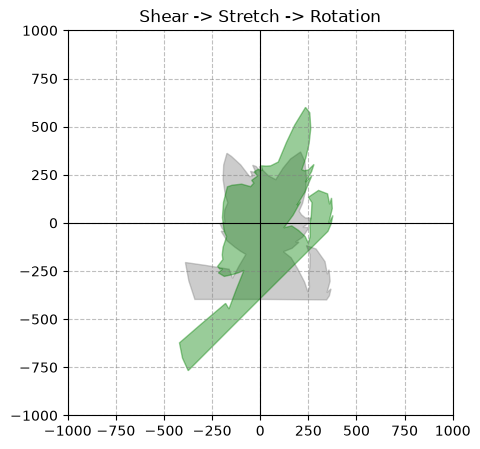

Shear -> Stretch -> Rotation
[[1.061 0.035]
 [1.061 1.025]]


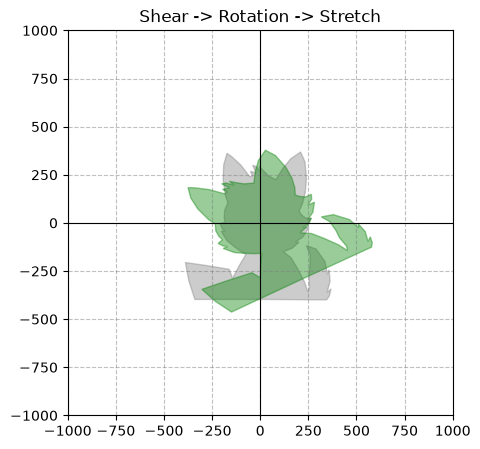

Shear -> Rotation -> Stretch
[[ 1.061 -0.53 ]
 [ 0.495  0.742]]


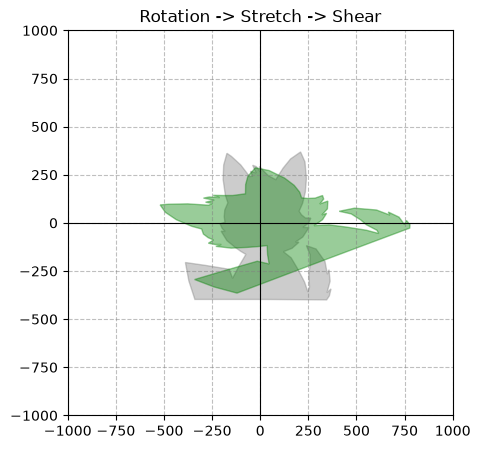

Rotation -> Stretch -> Shear
[[ 1.308 -0.813]
 [ 0.495  0.495]]


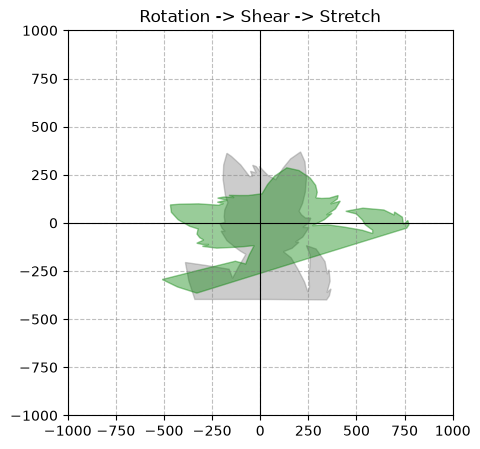

Rotation -> Shear -> Stretch
[[ 1.591 -0.53 ]
 [ 0.495  0.495]]


In [7]:
S = stretch_matrix(1.5, 0.7)
H = shear_matrix(0.5, 0)
R = rotation_matrix(np.deg2rad(45))

orders = {
    "Stretch -> Shear -> Rotation": R @ H @ S,
    "Stretch -> Rotation -> Shear": H @ R @ S,
    "Shear -> Stretch -> Rotation": R @ S @ H,
    "Shear -> Rotation -> Stretch": S @ R @ H,
    "Rotation -> Stretch -> Shear": H @ S @ R,
    "Rotation -> Shear -> Stretch": S @ H @ R,
}

for title, M in orders.items():
    show(lynx, M @ lynx, M, title)

In [8]:
Y1 = rotation(shear(stretch(lynx, 1.5, 0.7), 0.5, 0), np.deg2rad(45))
Y2 = (R @ H @ S) @ lynx
print(np.allclose(Y1, Y2)) # True Y1 = Y2

True


In [9]:
print(np.allclose(S @ H, H @ S))     # False S @ H ≠ H @ S
print(np.allclose(R @ S, S @ R))     # False R @ H ≠ H @ S

False
False


# Part 2

(11634, 3)
[[0, 1, 2], [1, 6, 7], [6, 1, 0]]
[[ 19.6172 118.1    140.1   ]
 [ 10.5766 108.108  136.696 ]
 [ 18.9919 111.778  136.696 ]
 ...
 [136.908  337.262  141.768 ]
 [136.908  340.756  139.544 ]
 [136.908  340.756  139.544 ]]


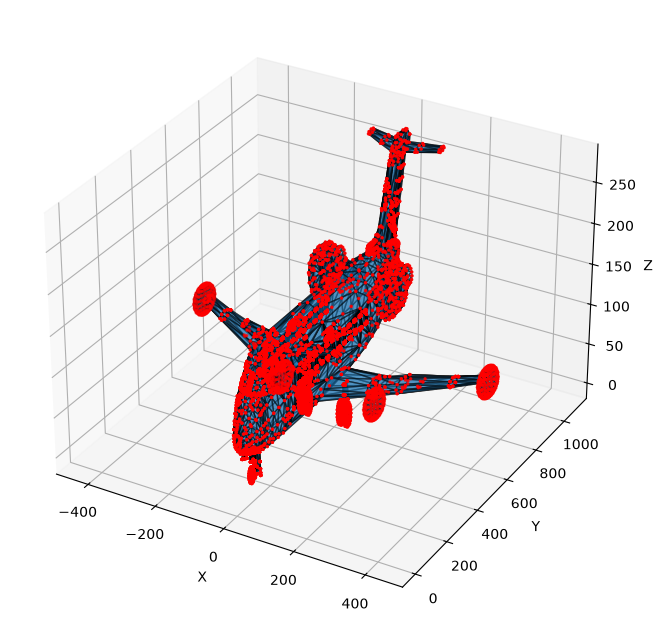

In [10]:
import numpy as np
from io_off import read_off
from plotting import plot_off
from transforms3d import (rotate_xy, rotate_yz, rotate_xz,
                          rotate_xy_matrix, rotate_yz_matrix, rotate_xz_matrix)

vertices, faces = read_off("data/airplane_0627.off")
print(vertices.shape)
print(faces[:3])
print(vertices)

plot_off(vertices, faces)

### Task 3

Rotation 45° in the xy plane (about the z axis)
[[ 0.707 -0.707  0.   ]
 [ 0.707  0.707  0.   ]
 [ 0.     0.     1.   ]]


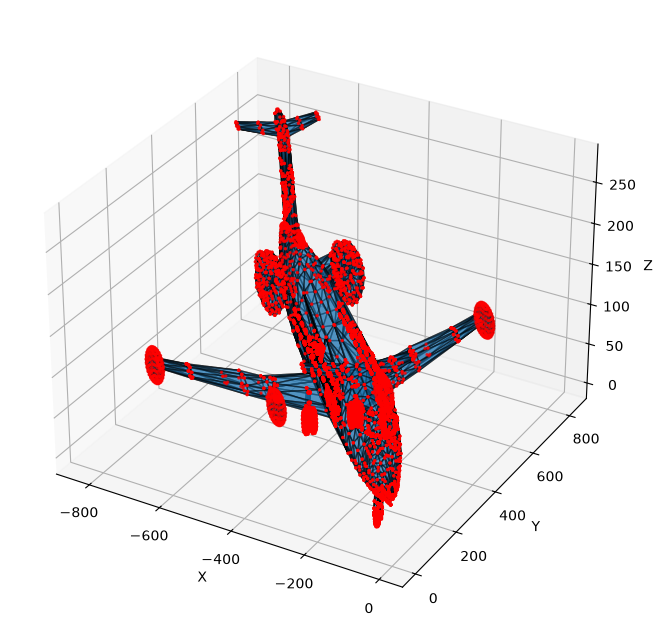

Rotation 45° in the yz plane (about the x axis)
[[ 1.     0.     0.   ]
 [ 0.     0.707 -0.707]
 [ 0.     0.707  0.707]]


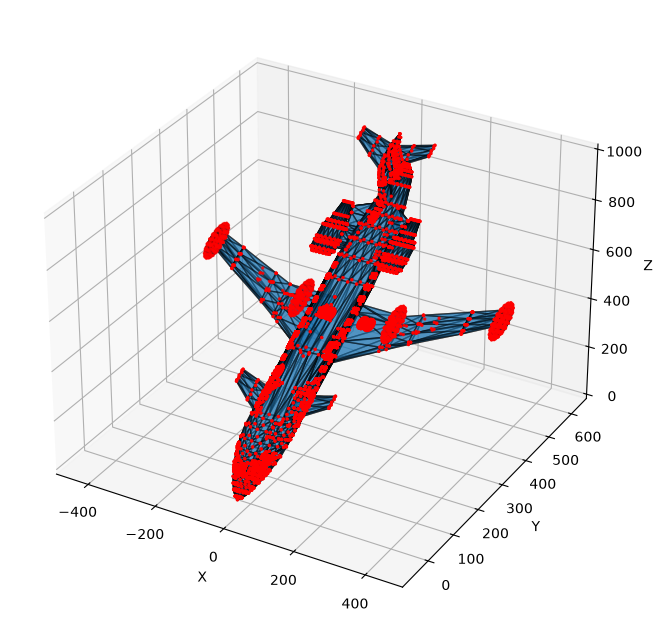

Rotation 45° in the xz plane (about the y axis)
[[ 0.707  0.    -0.707]
 [ 0.     1.     0.   ]
 [ 0.707  0.     0.707]]


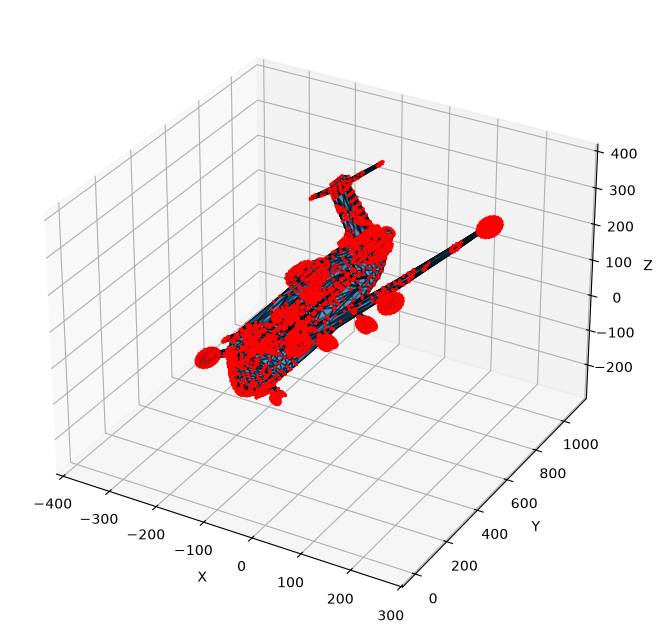

In [11]:
theta = np.deg2rad(45)

print("Rotation 45° in the xy plane (about the z axis)")
print(np.round(rotate_xy_matrix(theta), 3))
plot_off(rotate_xy(vertices, theta), faces)

print("Rotation 45° in the yz plane (about the x axis)")
print(np.round(rotate_yz_matrix(theta), 3))
plot_off(rotate_yz(vertices, theta), faces)

print("Rotation 45° in the xz plane (about the y axis)")
print(np.round(rotate_xz_matrix(theta), 3))
plot_off(rotate_xz(vertices, theta), faces)

### Task 4

Total matrix of the transformation
[[ 0.127 -0.78  -0.612]
 [ 0.354  0.612 -0.707]
 [ 0.927 -0.127  0.354]]


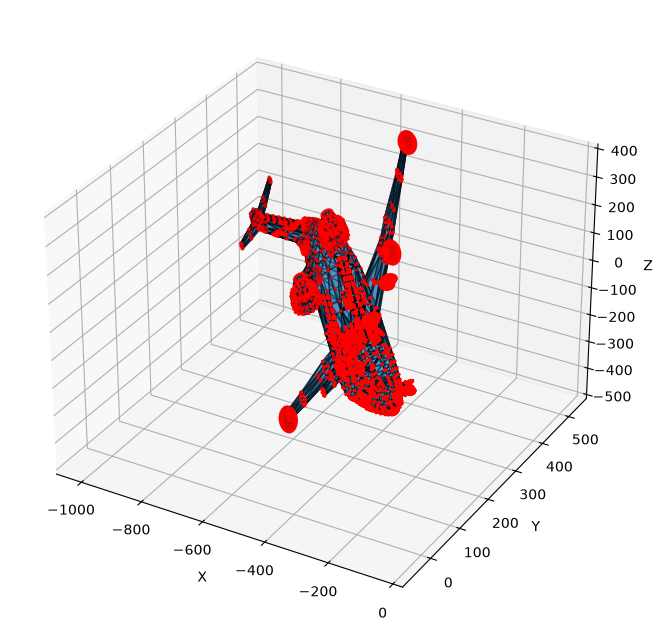

True
True
0.9999999999999999


In [12]:
a1, a2, a3 = np.deg2rad(30), np.deg2rad(45), np.deg2rad(60)

# first xy, then yz, then xz
W = rotate_xz(rotate_yz(rotate_xy(vertices, a1), a2), a3)

# the same as one total matrix: the first applied is the rightmost
M = rotate_xz_matrix(a3) @ rotate_yz_matrix(a2) @ rotate_xy_matrix(a1)

print("Total matrix of the transformation")
print(np.round(M, 3))
plot_off(W, faces)

print(np.allclose((M @ vertices.T).T, W))      # True: total matrix == step by step
print(np.allclose(M.T @ M, np.eye(3)))         # True: the result is still a rotation
print(np.linalg.det(M))                        # 1.0

#### Just for fun

In [13]:
from plotting import visualize_off

visualize_off(vertices, faces)                                   # original airplane
visualize_off(rotate_xy(vertices, np.deg2rad(45)), faces)        # rotated: xy, 45°
visualize_off(W, faces)                                          # Task 4 result

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


## Theoretical questions 2 points
- 1. `0.25pts` What are linear transformations?
- 2. `0.25pts` What is a linear transformation matrix and how can it be interpreted?
- 3. `0.25pts` What features and properties does a rotation matrix have?
- 4. `0.25pts` Suppose some arbitrary linear transformation has been performed; how do you find the linear transformation matrix that will return everything to its original form? Is it always possible to perform an inverse transformation?
- 5. `1pts` The absolute value of the determinant of a transformation matrix is less than 1, what conclusions can be drawn about this transformation (how does space change under this transformation)? What if it is greater than 1? Equal to 1? Equal to 0?

## My answers
1. Transformation must satisfy:
1. I've watched the video (https://youtu.be/kYB8IZa5AuE?si=5Gz-npuivEgF4g30) before doing this Lab and, in short, for example we have 2 vectors a and b, let's plus them up so v = a + b. Now we transform them and we can see how a and b changed, and knowing only that we can define that v = a*(transform vector) + b*(transform vector). So we can make a conclusion that A = (transform vector, transform vector) and then A - our transform matrix.